---
title: "Classification: Logistic Regression"
format: html
jupyter: python3
dir: ltr
---

In [19]:
import pandas as pd
import numpy as np

We have seen the x-axis for the independent variable, and y-axis for the dependent, target variable for regression.

In **classification** problems, we usually start with:

- at least **2 independent variables**: $x_1$ and $x_2$
- and try to classify **a binary target**: $y=\{0,1\}$

Let's make up some data (X, y):

In [20]:
from sklearn.datasets import make_blobs

centers = [
    [5, -5],
    [5, 5]
]

X, y = make_blobs(
    n_samples=100,
    centers=centers,
    random_state=40
)

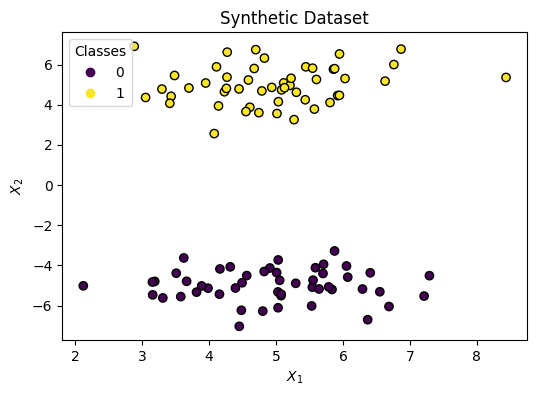

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))

scatter = ax.scatter(
    x=X[:, 0],
    y=X[:, 1],
    c=y, # color
    edgecolor="black"
)

ax.set(
    title="Synthetic Dataset",
    xlabel="$X_1$",
    ylabel="$X_2$"
)
_ = ax.legend(*scatter.legend_elements(), title="Classes")

## Decision Boundary

We need to draw a **Line** that splits the two classes. We can do that with the following formula:

$$
h(x) = w_1 x_1 + w_2 x_2 + b
$$

With this in mind, the graph will have both axes for the independent variables ($x_1$ and $x_2$) without showing the target $y$.

Changing the parameters has the following effect:

- Rotation: $w_1$ and $w_2$
- Shifting: $b$

![Decision Boundary](./assets/decision_boundary_equation.gif){height=300}

Fitting the parameters: $w_1, w_2, b$ sets the **Decision Boundary** between two classes: $y=0, y=1$.

In [22]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Let's look at the learned parameters:

In [27]:
print("w1: ", model.coef_[0][0].round(2))
print("w2: ", model.coef_[0][1].round(2))
print("b : ", model.intercept_[0].round(2))

w1:  -0.04
w2:  1.28
b :  0.34


Now let's plot the decision boundary:

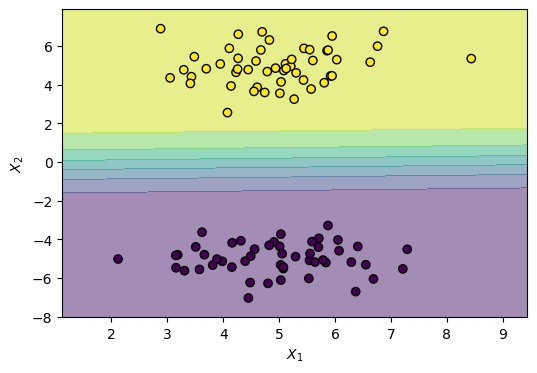

In [6]:
from sklearn.inspection import DecisionBoundaryDisplay

fig, ax = plt.subplots(figsize=(6, 4))

DecisionBoundaryDisplay.from_estimator(
    estimator=model,
    X=X,
    ax=ax,
    response_method="predict_proba",
    alpha=0.5,
    xlabel="$X_1$",
    ylabel="$X_2$"
)

scatter = ax.scatter(
    x=X[:, 0],
    y=X[:, 1],
    c=y,
    edgecolor="k"
)

Notice the gradual shift in color. That's because `LogisticRegression` models a smooth probability, where the middle is a `0.50` (equal) probability of both classes, rather than a hard threshold.

### The Sigmoid Function

This is accomplished using a **logistic function** (also known as **sigmoid function**), which looks like this:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

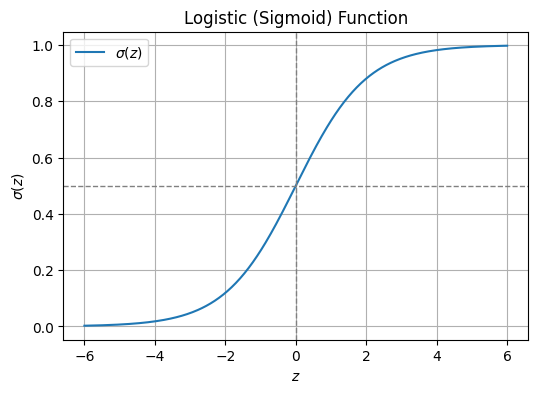

In [17]:
import numpy as np
import matplotlib.pyplot as plt


def sigmoid(z: np.ndarray) -> np.ndarray:
    return 1 / (1 + np.exp(-z))


z = np.linspace(-6, 6, 400)
sigma = sigmoid(z)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(z, sigma, label=r"$\sigma(z)$")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax.axvline(0.0, color="gray", linestyle="--", linewidth=1)
ax.set(
    title="Logistic (Sigmoid) Function",
    xlabel=r"$z$",
    ylabel=r"$\sigma(z)$",
)
ax.legend()
ax.grid(True)
plt.show()

### Demo: Sigmoid

Play with the [Desmos](https://www.desmos.com/calculator/c70sbcr6fq) demo and notice how:

- Adjusting the intercept $w_0$ shifts the curve left or right
- Updating $w_1$ affects the slope of the S-curve.
  -  Higher absolute values make the curve steeper
  -  While lower values make it more gradual

### Decision Threshold

The suffix "Regression" often causes confusion, but it is technically accurate. Logistic regression is fundamentally a regression algorithm because **it estimates a continuous numerical value: a probability between `0` and `1`**.

$$
0 \le p \le 1
$$

It is also known in the literature as:

- logit regression
- maximum-entropy classification (MaxEnt)
- log-linear classifier

It only becomes a classifier when we apply a **decision threshold** to that probability. For example, a standard rule is:

- `if p >= 0.5`: `y = 1`
- `if p <  0.5`: `y = 0`

![Sigmoid Function with Decision Bound](./assets/sigmoid_with_decision_bound.png)

<iframe src="classification_threshold.html" width="100%" height="500px"></iframe>

We simply plug our decision boundary equation. Read: "the probability that $y=1$ given $x$ (the data) is equal to":

$$
p(y=1|x) = \frac{1}{1 + e^{-(h(x))}} = \frac{1}{1 + e^{-(w_1 x_1 + w_2 x_2 + b)}}
$$



We can look at it in 3D, where **height corresponds the probability of y being 1 given x1 and x2**:

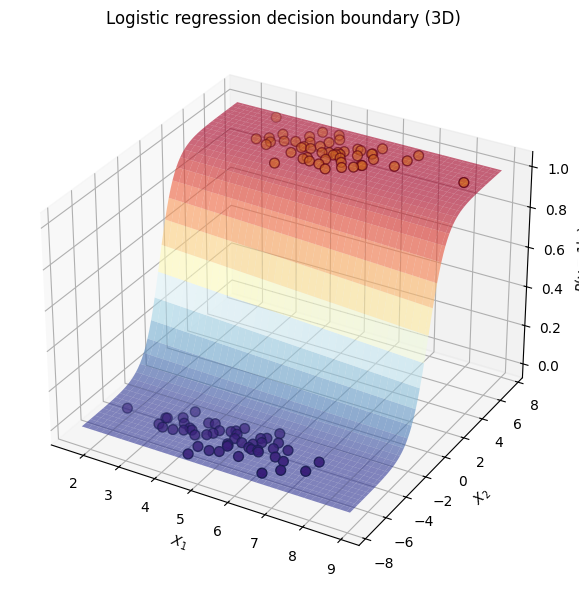

In [7]:
# 3D Plot: decision boundary as probability surface using meshgrid
import numpy as np

# Create meshgrid over the feature space (same range as the 2D plot)
x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 80), np.linspace(x2_min, x2_max, 80))

# Stack grid points and get P(y=1) from the logistic regression model
X_grid = np.c_[xx1.ravel(), xx2.ravel()]
Z = model.predict_proba(X_grid)[:, 1]  # probability of class 1
Z = Z.reshape(xx1.shape)

# 3D figure: x1, x2 on the base, probability on the z-axis
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(xx1, xx2, Z, alpha=0.6, cmap="RdYlBu_r")
ax.scatter(X[:, 0], X[:, 1], y, c=y, edgecolor="k", s=50)
ax.set(xlabel="$X_1$", ylabel="$X_2$", zlabel="$P(y=1|x)$", title="Logistic regression decision boundary (3D)")
plt.tight_layout()
plt.show()

## How It Learns: Log Loss

Unlike standard linear regression, which minimizes the Mean Squared Error (the distance between predicted and actual points), logistic regression optimizes a cost function called **Log Loss** (or **Binary Cross-Entropy**).

### Binary Cross Entropy

$$BCE = - \frac{1}{m} \sum_{i=1}^m \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

Where

* **$BCE$**: The total log loss calculated across the entire dataset.
* **$m$**: The total number of observations.
* **$y_i$**: The true, discrete binary label for the $i$-th observation (strictly 0 or 1).
* **$\hat{y}_i$**: The model's predicted probability that the $i$-th observation belongs to class 1 (a continuous value bounded strictly between 0 and 1).
* **$\log$**: The natural logarithm (base $e$).

![BCE Loss Curve](./assets/bce_loss.png){height=450}

### Categorical Cross-Entropy

When classifying more than two mutually exclusive categories, the binary log loss generalizes into categorical cross-entropy.

$$
CCE = -\frac{1}{m} \sum_{i=1}^m \sum_{k=1}^K y_{i,k} \log(\hat{y}_{i,k})
$$

Where:

* **$K$**: The total number of discrete classes.
* **$y_{i,k}$**: A binary indicator (strictly 0 or 1) denoting whether class $k$ is the correct ground-truth classification for observation $i$.
* **$\hat{y}_{i,k}$**: The model's predicted probability that observation $i$ belongs to class $k$.

Below is an animated version showing how the Logistic curve learns in 3D:

![Figure: animated loss curve and sigmoid with 2 variables and 1 target](https://miro.medium.com/v2/resize:fit:1152/1*IsOs8KXweJy4uFcSRc45RQ.gif)

### Beyond Binary Classification

To extend the algorithm beyond binary classification and into **multi-class classification**, there are two approaches:

1. **Multinomial**: Learns all classes **jointly**; using the CCE loss (recommended in practice)
2. **One vs Rest**: One binary classifier **per class**; using multiple BCE losses (used here to demonstrate the sigmoid curve in 3D)

We demonstrate the difference by going through the following steps:

1. Generate a 3-class dataset  
2. Train multinomial and one-vs-rest logistic regression  
3. Plot decision boundaries (regions from `predict`)  
4. Plot lines (where p(class) = 0.5)

## 1. Dataset

Synthetic 3-class data with `sklearn.datasets.make_blobs`:

In [8]:
import numpy as np
from sklearn.datasets import make_blobs

centers = [
    [-5, 0],
    [0, 1.5],
    [5, -1]
]

X, y = make_blobs(
    n_samples=1_000,
    centers=centers,
    random_state=40
)

transformation = [
    [0.4, 0.2],
    [-0.4, 1.2]
]
X = np.dot(X, transformation)

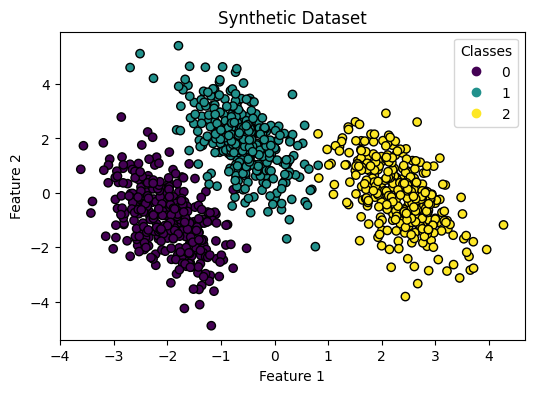

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))

scatter = ax.scatter(
    X[:, 0], # x-axis
    X[:, 1], # y-axis
    c=y,     # color by class
    edgecolor="black"
)
ax.set(
    title="Synthetic Dataset",
    xlabel="Feature 1",
    ylabel="Feature 2"
)
_ = ax.legend(*scatter.legend_elements(), title="Classes")

## 2. Train both classifiers

Multinomial and one-vs-rest logistic regression on the same data.



In [10]:
from sklearn.linear_model import LogisticRegression

logistic_regression_multinomial = LogisticRegression()
logistic_regression_multinomial.fit(X, y)
accuracy_multinomial = logistic_regression_multinomial.score(X, y)
print(accuracy_multinomial)

0.995


In [11]:
from sklearn.multiclass import OneVsRestClassifier

logistic_regression_ovr = OneVsRestClassifier(LogisticRegression())
logistic_regression_ovr.fit(X, y)
accuracy_ovr = logistic_regression_ovr.score(X, y)
print(accuracy_ovr)

0.976


## 3. Decision boundaries

Regions from `predict` for each model.



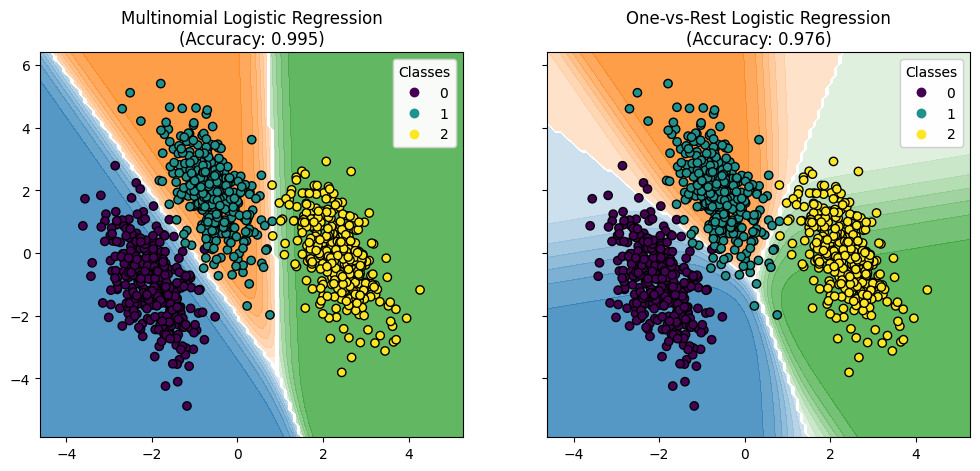

In [15]:
from sklearn.inspection import DecisionBoundaryDisplay

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for model, title, ax in [
    (
        logistic_regression_multinomial,
        f"Multinomial Logistic Regression\n(Accuracy: {accuracy_multinomial:.3f})",
        ax1,
    ),
    (
        logistic_regression_ovr,
        f"One-vs-Rest Logistic Regression\n(Accuracy: {accuracy_ovr:.3f})",
        ax2,
    ),
]:
    DecisionBoundaryDisplay.from_estimator(
        model,
        X,
        ax=ax,
        response_method="predict_proba",
        alpha=0.8,
    )
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")
    legend = ax.legend(*scatter.legend_elements(), title="Classes")
    ax.add_artist(legend)
    ax.set_title(title)

It is helpful to see the one-vs-rest plot in 3D, we'll have 3 separate plots where the Positive class is lifted up (because it's probability is maximized):

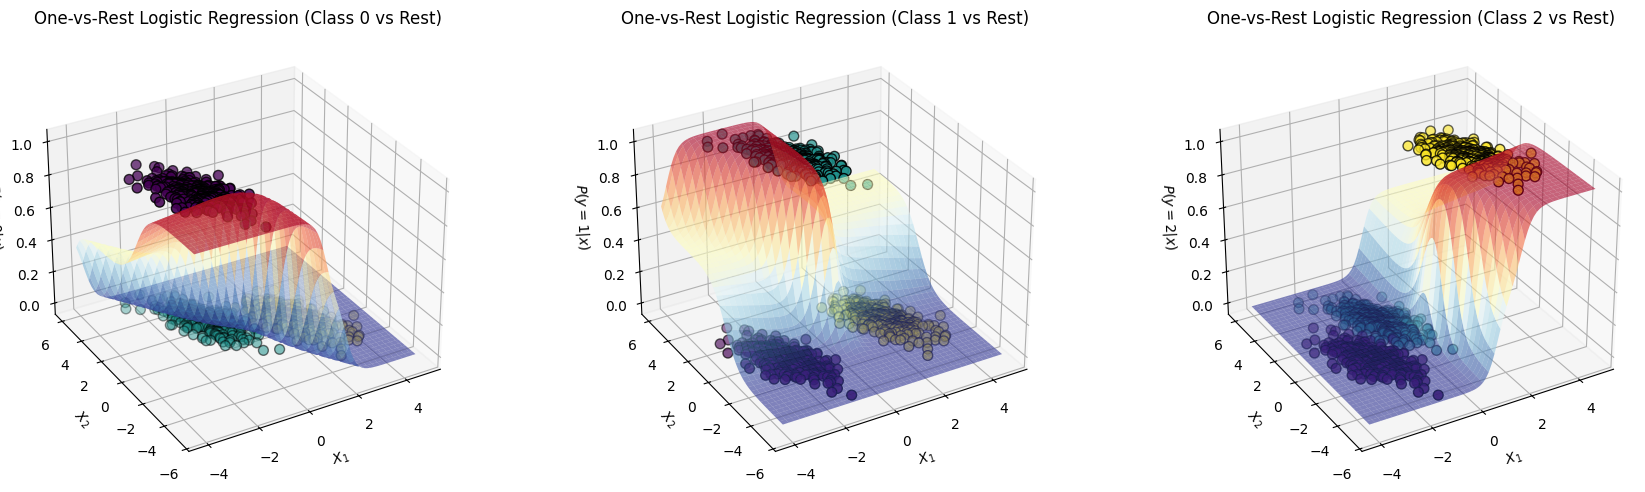

In [14]:
# 3D Plots: decision boundaries as probability surfaces for one-vs-rest logistic regression (each class)
import numpy as np

# Create meshgrid over the feature space (same range as the 2D plot)
x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 80), np.linspace(x2_min, x2_max, 80))

# Stack grid points for predictions
X_grid = np.c_[xx1.ravel(), xx2.ravel()]

# Make three 3D plots: probability surface for each of three classes
fig = plt.figure(figsize=(18, 5))

classes = np.unique(y)
for i, class_idx in enumerate(classes):
    Z = logistic_regression_ovr.predict_proba(X_grid)[:, class_idx]
    Z = Z.reshape(xx1.shape)
    ax = fig.add_subplot(1, 3, i + 1, projection="3d")
    # Plot the probability surface for class class_idx
    surf = ax.plot_surface(xx1, xx2, Z, alpha=0.6, cmap="RdYlBu_r")
    # Scatter the training data with its true class as color
    ax.scatter(X[:, 0], X[:, 1], (y == class_idx).astype(float), c=y, edgecolor="k", s=50)
    ax.set(
        xlabel="$X_1$",
        ylabel="$X_2$",
        zlabel=f"$P(y={class_idx}|x)$",
        title=f"One-vs-Rest Logistic Regression (Class {class_idx} vs Rest)"
    )
    ax.view_init(elev=30, azim=-120)  # Optional: adjust view

plt.tight_layout()
plt.show()